In [2]:
import pandas as pd

df = pd.read_csv('../data/my_dataset.csv')
df.head()

,OyuncuID,Yas,Kayit_Tarihi,Son_Giris,Ilkbahar_Saati,Yaz_Saati,Sonbahar_Saati,Kis_Saati,Toplam_Saat,OyuncuSeviyesi,Churn_Durumu,Hesap_Yasi
0,1000,27,2023-08-24,2026-04-20,119,114,138,135,508,45,1,2.86
1,1001,25,2023-09-21,2026-03-09,97,109,127,137,472,43,1,2.78
2,1002,14,2026-04-20,2026-06-15,21,26,0,0,47,13,0,0.20
3,1003,17,2023-10-09,2026-06-06,141,335,118,136,732,54,1,2.73
4,1004,43,2025-11-19,2026-04-07,18,0,6,43,68,16,1,0.62


In [24]:
df.isnull().sum()

OyuncuID          0
Yas               0
Kayit_Tarihi      0
Son_Giris         0
Ilkbahar_Saati    0
Yaz_Saati         0
Sonbahar_Saati    0
Kis_Saati         0
Toplam_Saat       0
OyuncuSeviyesi    0
Churn_Durumu      0
Hesap_Yasi        0
Girilmeyen_Gun    0
dtype: int64

In [25]:
df.describe()

,OyuncuID,Yas,Kayit_Tarihi,Son_Giris,Ilkbahar_Saati,Yaz_Saati,Sonbahar_Saati,Kis_Saati,Toplam_Saat,OyuncuSeviyesi,Churn_Durumu,Hesap_Yasi,Girilmeyen_Gun
count,10000.00000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5999.50000,22.291000,2025-07-08 08:26:00.960000,2026-03-03 14:52:30.720000,30.157100,52.728000,29.932900,32.743800,146.283600,17.997500,0.586500,0.979270,119.380200
min,1000.00000,12.000000,2023-07-03 00:00:00,2023-07-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,3499.75000,12.000000,2024-09-10 00:00:00,2026-02-02 00:00:00,0.000000,1.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000
50%,5999.50000,19.000000,2025-10-12 00:00:00,2026-05-13 00:00:00,11.000000,1.000000,0.000000,12.000000,56.000000,15.000000,1.000000,0.700000,49.000000
75%,8499.25000,29.000000,2026-07-01 00:00:00,2026-07-01 00:00:00,46.000000,72.250000,46.000000,46.000000,258.000000,32.000000,1.000000,1.800000,149.000000
max,10999.00000,60.000000,2026-07-01 00:00:00,2026-07-01 00:00:00,141.000000,449.000000,140.000000,139.000000,857.000000,58.000000,1.000000,3.000000,1085.000000
std,2886.89568,10.982913,NaN,NaN,37.550841,83.193356,38.225624,40.078653,183.739273,15.655702,0.492486,0.984583,181.815505


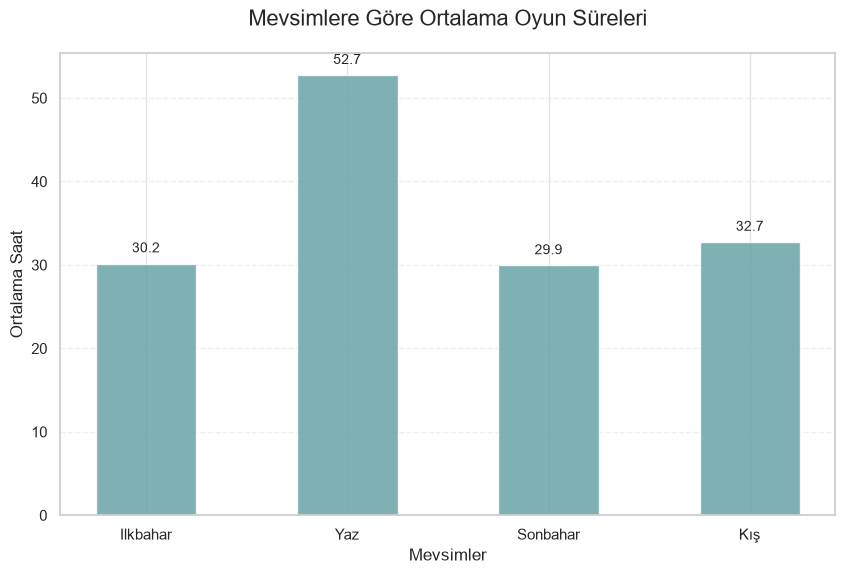

In [26]:
import matplotlib.pyplot as plt

# Mevsimleri sıralayalım
mevsimler = ['Ilkbahar', 'Yaz', 'Sonbahar', 'Kış']

# Mevsimsel ortalamaları alalım
mevsimlik_ortalamalar = [
    df['Ilkbahar_Saati'].mean(),
    df['Yaz_Saati'].mean(),
    df['Sonbahar_Saati'].mean(),
    df['Kis_Saati'].mean()
]

plt.figure(figsize=(10, 6))


bars = plt.bar(mevsimler, mevsimlik_ortalamalar, color='#5F9EA0', alpha=0.8, width=0.5)


plt.title('Mevsimlere Göre Ortalama Oyun Süreleri', fontsize=16, pad=20)
plt.ylabel('Ortalama Saat', fontsize=12)
plt.xlabel('Mevsimler', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval, 1), ha='center', va='bottom', fontsize=10)

plt.show()

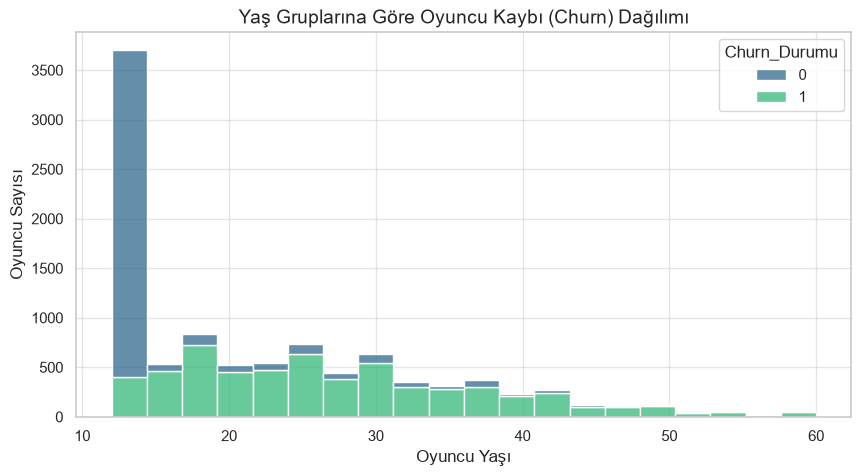

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin daha şık görünmesi için seaborn teması
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

# x parametresini 'Yas' olarak güncelledik
sns.histplot(data=df, x='Yas', hue='Churn_Durumu',
             multiple='stack',
             palette='viridis',
             bins=20)

plt.title('Yaş Gruplarına Göre Oyuncu Kaybı (Churn) Dağılımı', fontsize=14)
plt.xlabel('Oyuncu Yaşı')
plt.ylabel('Oyuncu Sayısı')
plt.show()

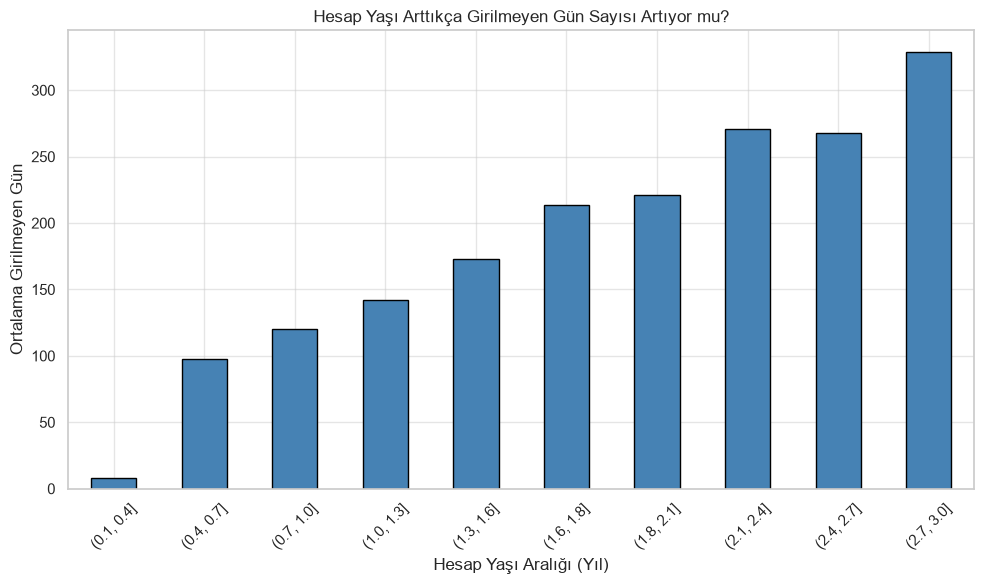

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/my_dataset.csv")  # yolunuzu kendinize göre ayarlayın

# Girilmeyen gün sayısını hesapla
df["Son_Giris"] = pd.to_datetime(df["Son_Giris"])
bugun = pd.Timestamp.now()
df["Girilmeyen_Gun"] = (bugun - df["Son_Giris"]).dt.days

# Hesap yaşını gruplara ayır (precision=0 ile aralık sınırları tam sayıya yuvarlanır)
df["Hesap_Yasi_Grup"] = pd.cut(df["Hesap_Yasi"], bins=10, precision=0)
grup_ortalama = df.groupby("Hesap_Yasi_Grup", observed=True)["Girilmeyen_Gun"].mean()

# Sütun grafik
plt.figure(figsize=(10, 6))
grup_ortalama.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Hesap Yaşı Arttıkça Girilmeyen Gün Sayısı Artıyor mu?")
plt.xlabel("Hesap Yaşı Aralığı (Yıl)")
plt.ylabel("Ortalama Girilmeyen Gün")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
